In [183]:
import copy
import pandas as pd
import numpy as np
from tqdm import tqdm
from ray import tune
import matplotlib.pyplot as plt
import pytagi.metric as metric
from pytagi import Normalizer as normalizer
from canari import (
    DataProcess,
    Model,
    ModelAssemble,
    Optimizer,
    plot_data,
    plot_prediction,
    plot_states,
)
from canari.component import LocalTrend, LstmNetwork, WhiteNoise

In [184]:
# # Read data
data_file = "/Users/vuongdai/Desktop/backup_canari/data/icold_2022.csv"
df_raw = pd.read_csv(data_file, delimiter=",", header=0,
                     names=["datetime","cb2","cb3","waterlevel","temp_a","temp_b"],
                     usecols=["datetime","cb2","waterlevel"],
                     index_col="datetime", parse_dates=True)

# Resample
df_raw = df_raw.loc['2000-01-30':'2012-12-31']
df = df_raw.resample("W").last()

# Data pre-processing
output_col = [0]

In [185]:
# 
NUM_EPOCH = 50
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
OUTPUT_COL = [0] # Target

# seed
rng = np.random.default_rng(1)
seed = rng.integers(0, 1000)      
# seed = 1   

In [186]:
def build_data(covar_num_lag):
    df_lagged = DataProcess.add_lagged_columns(df, [0, covar_num_lag])
    data_processor = DataProcess(
        data=df_lagged,
        time_covariates=["week_of_year"],
        train_split=TRAIN_SPLIT,
        validation_split=VAL_SPLIT,
        output_col=output_col,
    )
    num_features = covar_num_lag + 3

    return data_processor, num_features

In [137]:
# data_processor, num_features = build_data(2)
# data_processor.data.head()

In [187]:
def model_with_parameters(param):
    (
        data_processor,
        num_features,
    ) = build_data(param["covar_num_lag"])

    train_data, validation_data, test_data, _ = data_processor.get_splits()

    # Target model
    model = Model(
        LstmNetwork(
            look_back_len=param["target_look_back_len"],
            # look_back_len=1,
            num_features=num_features,
            num_layer=1,
            num_hidden_unit=50,
            manual_seed=seed,
            smoother=False,
        ),
        WhiteNoise(std_error=param["target_sigma_v"]),
    )
    # 
    validation_obs = data_processor.get_data("validation").flatten()

    mu_validation_preds_optim = None
    std_validation_preds_optim = None
    mu_test_preds_optim = None
    std_test_preds_optim = None
    num_test = len(test_data["y"])
    num_val = len(validation_data["y"])
    
    for epoch in range(NUM_EPOCH):
        (mu_validation_preds, std_validation_preds, states) = model.lstm_train(
            train_data=train_data,
            validation_data=validation_data,
        )

        # Validation
        # Tartget predictions
        mu_validation_preds = normalizer.unstandardize(
            mu_validation_preds,
            data_processor.scale_const_mean[output_col],
            data_processor.scale_const_std[output_col],
        )
        std_validation_preds = normalizer.unstandardize_std(
            std_validation_preds,
            data_processor.scale_const_std[output_col],
        )

        mse = metric.mse(mu_validation_preds, validation_obs)
        validation_log_lik = metric.log_likelihood(
            prediction=mu_validation_preds,
            observation=validation_obs,
            std=std_validation_preds,
        )

        # Early-stopping on the validation set
        model.early_stopping(
            evaluate_metric=mse,
            current_epoch=epoch,
            max_epoch=NUM_EPOCH,
        )

        # Metric used by the Optimizer
        model.metric_optim = model.early_stop_metric

        if epoch == model.optimal_epoch:
            mu_validation_preds_optim = mu_validation_preds
            std_validation_preds_optim = std_validation_preds

        if model.stop_training:
            break

    return (
        model,
        data_processor,
        mu_validation_preds_optim,
        std_validation_preds_optim,
        )


In [139]:
# # Hyperparameter optimization with TPE sampling
param_space = {
    "target_look_back_len": [1, 52],
    "target_sigma_v": tune.loguniform(1e-2, 2e-1),
    "covar_num_lag": [0, 26], 
}

model_optimizer = Optimizer(
    model=model_with_parameters,
    param=param_space,
    num_optimization_trial=80,
    num_startup_trials=30,
    mode="min",
    max_concurrent=6,
)
model_optimizer.optimize()
param_optim = model_optimizer.get_best_param()

#  1/80 - Metric: 18.549 - Parameter: {'target_look_back_len': 36, 'target_sigma_v': 0.05530231689655109, 'covar_num_lag': 18}
#  2/80 - Metric: 8.754 - Parameter: {'target_look_back_len': 34, 'target_sigma_v': 0.0336508202597577, 'covar_num_lag': 15}
#  3/80 - Metric: 8.873 - Parameter: {'target_look_back_len': 26, 'target_sigma_v': 0.030276976113039204, 'covar_num_lag': 6}
#  4/80 - Metric: 5.732 - Parameter: {'target_look_back_len': 9, 'target_sigma_v': 0.16999466030528604, 'covar_num_lag': 4}
#  5/80 - Metric: 8.911 - Parameter: {'target_look_back_len': 6, 'target_sigma_v': 0.024889227146669347, 'covar_num_lag': 4}
#  6/80 - Metric: 11.258 - Parameter: {'target_look_back_len': 47, 'target_sigma_v': 0.017215049749585324, 'covar_num_lag': 20}
#  7/80 - Metric: 31.992 - Parameter: {'target_look_back_len': 12, 'target_sigma_v': 0.07435560319077555, 'covar_num_lag': 6}
#  8/80 - Metric: 8.191 - Parameter: {'target_look_back_len': 4, 'target_sigma_v': 0.1918410063314042, 'covar_num_lag':

2026-09-23 14:23:50,522	INFO tune.py:1007 -- Wrote the latest version of all result files and experiment state to '/Users/vuongdai/ray_results/objective_2026-09-23_14-19-05' in 0.0258s.


# 80/80 - Metric: 9.111 - Parameter: {'target_look_back_len': 6, 'target_sigma_v': 0.10768019564168166, 'covar_num_lag': 10}
-----
Optimal parameters at trial #65. Best metric: 5.3110. Best print metric: None. Best param: {'target_look_back_len': 14, 'target_sigma_v': 0.13291793007743155, 'covar_num_lag': 10}.
-----


In [188]:
param_optim = {
    'target_look_back_len': 6, 
    'target_sigma_v': 0.10768019564168166, 
    'covar_num_lag': 10
    }

In [189]:
(   
    model,
    data_processor,
    mu_validation_preds_optim,
    std_validation_preds_optim,
) = model_with_parameters(param_optim)

In [190]:
# Test set
model.set_memory(time_step=data_processor.test_start - 1)

# Tartget predictions
_,_,test_data,_ = data_processor.get_splits()
mu_test_preds, std_test_preds,_ = model.forecast(data=test_data)

mu_test_preds = normalizer.unstandardize(
    mu_test_preds,
    data_processor.scale_const_mean[output_col],
    data_processor.scale_const_std[output_col],
)
std_test_preds = normalizer.unstandardize_std(
    std_test_preds,
    data_processor.scale_const_std[output_col],
)

In [191]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

mpl.rcParams.update({
    # Use LaTeX for text rendering — fonts will match your Beamer theme exactly
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{lmodern}",

    # Font sizes: Beamer default body is 11pt
    "font.size": 22,
    "axes.titlesize": 22,
    "axes.labelsize": 22,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 22,

    # Thin lines look better on slides
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "lines.linewidth": 1.5,

    # No right/top spines (cleaner on slides)
    "axes.spines.top": False,
    "axes.spines.right": False,
})

In [192]:
print(f"Seed            : {seed}")
print(f"Optimal parameters            : {param_optim}")

Seed            : 473
Optimal parameters            : {'target_look_back_len': 6, 'target_sigma_v': 0.10768019564168166, 'covar_num_lag': 10}


In [176]:
# import matplotlib as mpl
# import matplotlib.pyplot as plt
# import matplotlib.transforms as mtransforms
# import matplotlib.dates as mdates
# import matplotlib.ticker as mticker

# #  Plot
# fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# # Target model
# plot_data(
#     data_processor=data_processor,
#     standardization=False,
#     plot_column=output_col,
#     plot_nan=False,
#     validation_label="obs.",
# )
# plot_prediction(
#     data_processor=data_processor,
#     mean_validation_pred=mu_validation_preds_optim,
#     std_validation_pred=std_validation_preds_optim,
#     validation_label=[r"$\mu$", r"$\mu \pm 2\sigma$"],
#     color="blue",
#     num_std=2,
# )
# plot_prediction(
#     data_processor=data_processor,
#     mean_test_pred=mu_test_preds,
#     std_test_pred=std_test_preds,
#     color="blue",
#     num_std=2,
# )

# # --- Split boundaries on the x-axis ---
# time = data_processor.data.index
# t_start     = time[0]
# t_train_end = time[data_processor.train_end - 1]       # last train point
# t_val_end   = time[data_processor.validation_end - 1]  # last validation point
# t_end       = time[-1]

# # x in data units, y in axes fraction (0-1)
# trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)

# y_text = 1  # labels sit below the legend (lower value = further down)
# for label, (a, b) in {
#     "train":      (t_start, t_train_end),
#     "validation": (t_train_end, t_val_end),
#     "test":       (t_val_end, t_end),
# }.items():
#     mid = a + (b - a) / 2   # works for numbers and datetimes
#     ax.text(mid, y_text, label, transform=trans,
#             ha="center", va="top", fontsize=22,
#             bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

# # Legend inside the axes, at the top
# ax.legend(loc="upper center", bbox_to_anchor=(0.12, 1.1), ncol=1, frameon=False)

# # Axes formatting
# ax.xaxis.set_major_locator(mdates.YearLocator(base=2))    # a tick every 2 years
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))  # show only the year
# ax.xaxis.set_minor_locator(mticker.NullLocator())         # remove minor x-ticks
# ax.grid(False, which="both", axis="x")                    # remove vertical grid lines
# ax.set_ylim(-30, 25)   # (lower, upper); extra headroom for legend and labels
# ax.set_ylabel("Displacement [mm]")

# # Save
# fig.savefig("icold22_target_covar.pdf",
#             bbox_inches="tight",
#             pad_inches=0.02,
#             dpi=300)

# mpl.rcParams["pgf.texsystem"] = "pdflatex"
# mpl.rcParams["pgf.rcfonts"] = False
# fig.savefig("icold22_target_covar.pgf",
#             bbox_inches="tight",
#             pad_inches=0.02)

In [177]:
# #  Plot
# fig, ax = plt.subplots(1, 1, figsize=(10, 3), sharex=True)

# # Target model
# plot_data(
#     data_processor=data_processor,
#     standardization=False,
#     plot_column=[1],
#     plot_nan=False,
#     # validation_label="water level",
# )

# # --- Split boundaries on the x-axis ---
# # Adjust to however your data_processor stores the splits
# time = data_processor.data.index
# t_start     = time[0]
# t_train_end = time[data_processor.train_end - 1]       # last train point
# t_val_end   = time[data_processor.validation_end - 1]  # last validation point
# t_end       = time[-1]

# # plt.legend(loc="upper left", bbox_to_anchor=(0.0, 1.05))  # increase 1.05 to move it higher
# ax.xaxis.set_major_locator(mdates.YearLocator(base=2))      # a tick every 2 years
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))    # show only the year
# ax.xaxis.set_minor_locator(mticker.NullLocator())   # remove minor x-ticks
# ax.grid(False, which="both", axis="x")             # remove minor vertical g
# ax.set_ylabel("water level [m]")

# fig.savefig("icold22_wl_covar.pdf",
#             bbox_inches="tight",
#             pad_inches=0.02,      # tiny padding so nothing clips
#             dpi=300)

# mpl.rcParams["pgf.texsystem"] = "pdflatex"
# mpl.rcParams["pgf.rcfonts"] = False   # use rcParams fonts, not pgf defaults
# fig.savefig("icold22_wl_covar.pgf")

In [178]:
# ---- Load ----
df = pd.read_csv("/Users/vuongdai/GitHub/canari/examples/icold22/icold22_uni_predictions.csv")
val, test = df[df["split"] == "validation"], df[df["split"] == "test"]

mu_validation_preds_optim_univariate = val["mu"].to_numpy()
std_validation_preds_optim_univariate = val["std"].to_numpy()
mu_test_preds_univariate = test["mu"].to_numpy()
std_test_preds_univariate = test["std"].to_numpy()

In [193]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

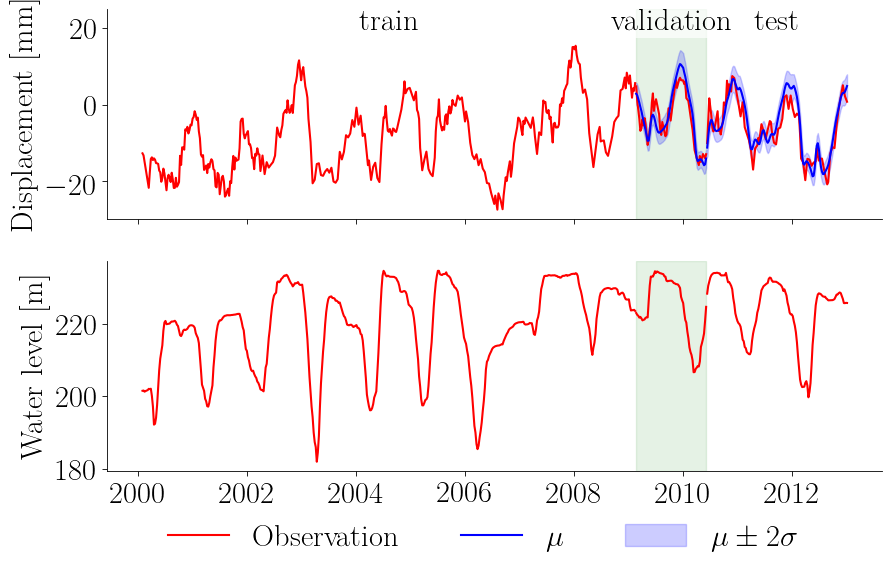

In [202]:

# --- Split boundaries on the x-axis ---
time = data_processor.data.index
t_start     = time[0]
t_train_end = time[data_processor.train_end - 1]       # last train point
t_val_end   = time[data_processor.validation_end - 1]  # last validation point
t_end       = time[-1]

splits = {
    "train":      (t_start, t_train_end),
    "validation": (t_train_end, t_val_end),
    "test":       (t_val_end, t_end),
}

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

# ===================== Subplot 1: Target model =====================
ax = axes[0]
plt.sca(ax)
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=output_col,
    plot_nan=False,
    validation_label="Observation",
)
plot_prediction(
    data_processor=data_processor,
    mean_validation_pred=mu_validation_preds_optim,
    std_validation_pred=std_validation_preds_optim,
    validation_label=[r"$\mu$", r"$\mu \pm 2\sigma$"],
    color="blue",
    num_std=2,
)
plot_prediction(
    data_processor=data_processor,
    mean_test_pred=mu_test_preds,
    std_test_pred=std_test_preds,
    color="blue",
    num_std=2,
)

trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
for label, (a, b) in splits.items():
    mid = a + (b - a) / 2
    ax.text(mid, 1, label, transform=trans,
            ha="center", va="top", fontsize=22,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1))

# ax.legend(loc="upper center", bbox_to_anchor=(0.12, 1.2), ncol=3, frameon=False)
ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.grid(False, which="both", axis="x")
ax.set_ylim(-30, 25)
ax.set_ylabel("Displacement [mm]")

# # ===================== Subplot 2: Univariate model =====================
# ax = axes[1]
# plt.sca(ax)
# plot_data(
#     data_processor=data_processor,
#     standardization=False,
#     plot_column=output_col,
#     plot_nan=False,
#     validation_label="obs.",
# )
# plot_prediction(
#     data_processor=data_processor,
#     mean_validation_pred=mu_validation_preds_optim_univariate,
#     std_validation_pred=std_validation_preds_optim_univariate,
#     validation_label=[r"$\mu$", r"$\mu \pm 2\sigma$"],
#     color="blue",
#     num_std=2,
# )
# plot_prediction(
#     data_processor=data_processor,
#     mean_test_pred=mu_test_preds_univariate,
#     std_test_pred=std_test_preds_univariate,
#     color="blue",
#     num_std=2,
# )

# ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
# ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
# ax.xaxis.set_minor_locator(mticker.NullLocator())
# ax.grid(False, which="both", axis="x")
# ax.set_ylim(-30, 25)
# ax.set_ylabel("Displacement [mm]")

# ===================== Subplot 3: Water level =====================
ax = axes[1]
plt.sca(ax)
plot_data(
    data_processor=data_processor,
    standardization=False,
    plot_column=[1],
    plot_nan=False,
)

ax.xaxis.set_major_locator(mdates.YearLocator(base=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_minor_locator(mticker.NullLocator())
ax.grid(False, which="both", axis="x")
ax.set_ylabel("Water level [m]")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels,
           loc="lower center", bbox_to_anchor=(0.5, -0.07),  # just above the figure
           ncol=len(labels), frameon=False)

# ===================== Save =====================
# Save
fig.savefig("icold22.pdf",
            bbox_inches="tight",
            pad_inches=0.02,
            dpi=300)

mpl.rcParams["pgf.texsystem"] = "pdflatex"
mpl.rcParams["pgf.rcfonts"] = False
fig.savefig("icold22.pgf",
            bbox_inches="tight",
            pad_inches=0.02)